# Many Agents and Many Apples - Predicting the Nearest Agent to the Apple using a CNN

In [1]:
from pathlib import Path
import pickle
import sys
import os
import random
import numpy as np
import sys
import torch
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

sys.path.append('../')
# Add the root directory to the Python path to find your modules

from models.reward_cnn import RewardCNNDecentralized
from config import MODEL_DIR, GRAPHS_DIR
import torch
from train_scripts.train_centralized_cnn import MODEL_SAVE_PATH
import matplotlib.pyplot as plt
from config import GRAPHS_DIR, OUT_DIR
from tqdm import tqdm


--- PyTorch is configured to use: cuda ---


# Generate Data

- Self-agent is always at index 0
- With probability p_pick, an apple is picked
- If an apple is picked, pick uniformly at random the agent id picker_id that picks apple and we ensure an apple is at picker_id's position, and no other agent can be in the same cell as an apple. The reward for self-agent is euclid_dist(self-agent's position - picker_id's position) if self-agent does not pick apple, and -1 if it did pick apple.
- If no apple is picked, self-agent get reward of 0


In [2]:
import numpy as np
from tqdm import tqdm
import random

def generate_probabilistic_apple_distance_dataset(num_samples, width, height, num_agents, s_target, p_pick=0.5):
    """
    Generates a dataset where the number of apples is probabilistic based on a target spawn rate.
    The reward is based on the Euclidean distance to a picked apple.

    - With probability `p_pick`, an agent picks an apple.
    - If an apple is picked, one agent is designated the "picker" and an apple is placed at its location.
      Other apples are spawned probabilistically in the grid. The reward for the self-agent (agent 0)
      is the Euclidean distance to the picker. If the self-agent is the picker, the reward is -1.
    - If no apple is picked, apples are spawned probabilistically, but never on top of an agent.
      The reward is 0.

    Args:
        num_samples (int): Number of data points to generate.
        width (int): Width of the grid.
        height (int): Height of the grid.
        num_agents (int): Number of agents in the grid.
        s_target (float): Target spawn rate, influencing the per-cell probability of an apple spawning.
                          This replaces the fixed `num_apples`.
        p_pick (float): Probability that an agent picks an apple in a given sample.

    Returns:
        list[dict]: A list of samples, where each sample is a dictionary with keys
                    'state', 'agent_pos', and 'reward'.
    """
    dataset = []
    total_cells = width * height
    all_coords_flat = np.arange(total_cells)

    # Calculate the per-cell spawn probability from the target rate
    p_cell = (num_agents / total_cells) * s_target if total_cells > 0 else 0

    for _ in tqdm(range(num_samples), desc=f"Generating {num_samples} samples"):
        agents_grid = np.zeros((height, width), dtype=np.int8)
        apples_grid = np.zeros((height, width), dtype=np.int8)

        # 1. Place all agents, ensuring unique positions
        agent_indices_flat = np.random.choice(all_coords_flat, size=num_agents, replace=False)
        agent_rows, agent_cols = np.unravel_index(agent_indices_flat, (height, width))
        agents_grid[agent_rows, agent_cols] = 1
        
        # The "self-agent" is always the first one placed
        self_agent_pos = (agent_rows[0], agent_cols[0])

        if np.random.rand() < p_pick:
            # --- SCENARIO 1: ONE AGENT PICKS AN APPLE ---
            
            # Choose a random agent to be the picker
            picker_index = np.random.randint(0, num_agents)
            picker_pos = (agent_rows[picker_index], agent_cols[picker_index])

            # Generate a probabilistic spawn mask for all apples
            spawn_mask = np.random.rand(height, width) < p_cell

            # Ensure an apple is at the picker's position
            spawn_mask[picker_pos] = True

            # Ensure no other agent is on a spawned apple
            # (Create a mask of all agents except the picker)
            other_agents_mask = (agents_grid == 1)
            other_agents_mask[picker_pos] = False
            spawn_mask[other_agents_mask] = False
            
            apples_grid[spawn_mask] = 1

            # Calculate reward based on distance to the picker
            if self_agent_pos == picker_pos:
                reward = -1.0
            else:
                reward = np.linalg.norm(np.array(self_agent_pos) - np.array(picker_pos))

        else:
            # --- SCENARIO 2: NO AGENT PICKS AN APPLE ---
            
            # Generate a probabilistic spawn mask
            spawn_mask = np.random.rand(height, width) < p_cell
            
            # Ensure no apples spawn on any agent
            spawn_mask[agents_grid == 1] = False
            
            apples_grid[spawn_mask] = 1
            
            # Reward is 0 when no apple is picked
            reward = 0.0
            
        state = {'agents': agents_grid, 'apples': apples_grid}
        dataset.append({'state': state, 'agent_pos': self_agent_pos, 'reward': reward})
        
    return dataset

# Parameters

In [3]:
# Set a seed for reproducibility!
np.random.seed(42)
random.seed(42)

# Data Parameters
TOTAL_TRAIN_SAMPLES = 100000
TOTAL_TEST_SAMPLES = 20000
WIDTH = 12
HEIGHT = 12
NUM_AGENTS = 9
S_TARGET = 1
PROBABILITY_AN_APPLE_IS_PICKED = 0.5

# Training Parameters
NUM_EPOCHS = 10  # Train over the full dataset 10 times
BATCH_SIZE = 64
LEARNING_RATE = 0.001

# Model Parameters
MLP_HIDDEN_FEATURES = 256
MLP_HIDDEN_LAYERS = 2


# Data

In [4]:
training_data = generate_probabilistic_apple_distance_dataset(
    TOTAL_TRAIN_SAMPLES, 
    WIDTH, HEIGHT, NUM_AGENTS, S_TARGET, PROBABILITY_AN_APPLE_IS_PICKED)
testing_data = generate_probabilistic_apple_distance_dataset(
    TOTAL_TEST_SAMPLES, WIDTH, HEIGHT, NUM_AGENTS, S_TARGET, PROBABILITY_AN_APPLE_IS_PICKED)

Generating 20000 samples: 100%|██████████| 20000/20000 [00:00<00:00, 47633.37it/s]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def visualize_state_counts(data, show_zeros=False, highlight_agent_pos=True, cell_fontsize=12, figsize=None):
    """
    Visualize agents and apples as separate numeric grids.
    - data: one entry like training_data[0]
    - show_zeros: if True, prints '0' for empty cells; otherwise leaves them blank
    - highlight_agent_pos: draws a green border around agent_pos cell
    - cell_fontsize: font size for numbers
    - figsize: tuple (w,h) to override default figure size
    (0,0) is top-left; first coord = row (down), second = column (right).
    """
    state = data['state']
    agents = np.array(state['agents'], dtype=int)
    apples = np.array(state['apples'], dtype=int)
    agent_pos = tuple(int(x) for x in data['agent_pos'])
    reward = float(data['reward'])
    rows, cols = agents.shape

    if figsize is None:
        figsize = (max(6, cols * 0.5 * 2), max(4, rows * 0.5))

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    grids = [(agents, "Agents (counts)"), (apples, "Apples (counts)")]

    for ax, (grid, title) in zip(axes, grids):
        # Set coordinate system so (0,0) is top-left
        ax.set_xlim(-0.5, cols - 0.5)
        ax.set_ylim(-0.5, rows - 0.5)
        ax.invert_yaxis()  # this makes row 0 appear at top
        ax.set_xticks(np.arange(cols))
        ax.set_yticks(np.arange(rows))
        ax.set_xticklabels(np.arange(cols))
        ax.set_yticklabels(np.arange(rows))
        ax.set_aspect('equal')
        ax.set_title(title)

        # draw each cell and the number (if nonzero or show_zeros)
        for r in range(rows):
            for c in range(cols):
                # white cell with black border
                rect = Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor='white', edgecolor='black', linewidth=0.8)
                ax.add_patch(rect)
                val = int(grid[r, c])
                if show_zeros or val != 0:
                    ax.text(c, r, str(val), ha='center', va='center', fontsize=cell_fontsize)

        # highlight the agent_pos cell (green border)
        if highlight_agent_pos:
            ar, ac = agent_pos
            if 0 <= ar < rows and 0 <= ac < cols:
                hl = Rectangle((ac - 0.5, ar - 0.5), 1, 1, facecolor='none', edgecolor='green', linewidth=2)
                ax.add_patch(hl)

    fig.suptitle(f"Agent position: {agent_pos}    Reward: {reward:.3f}", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return fig, axes


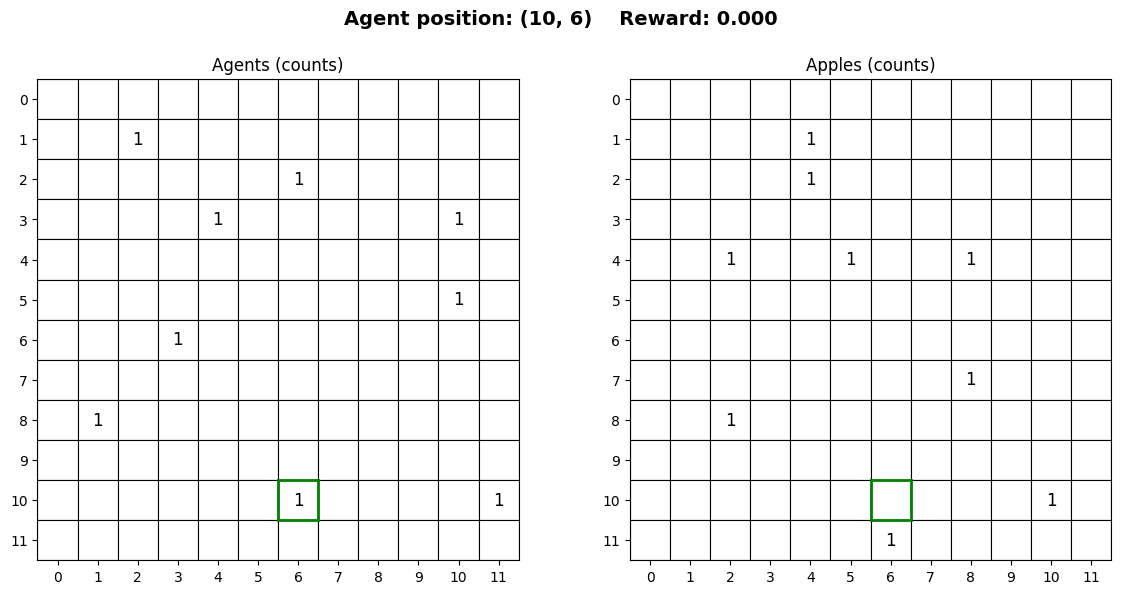

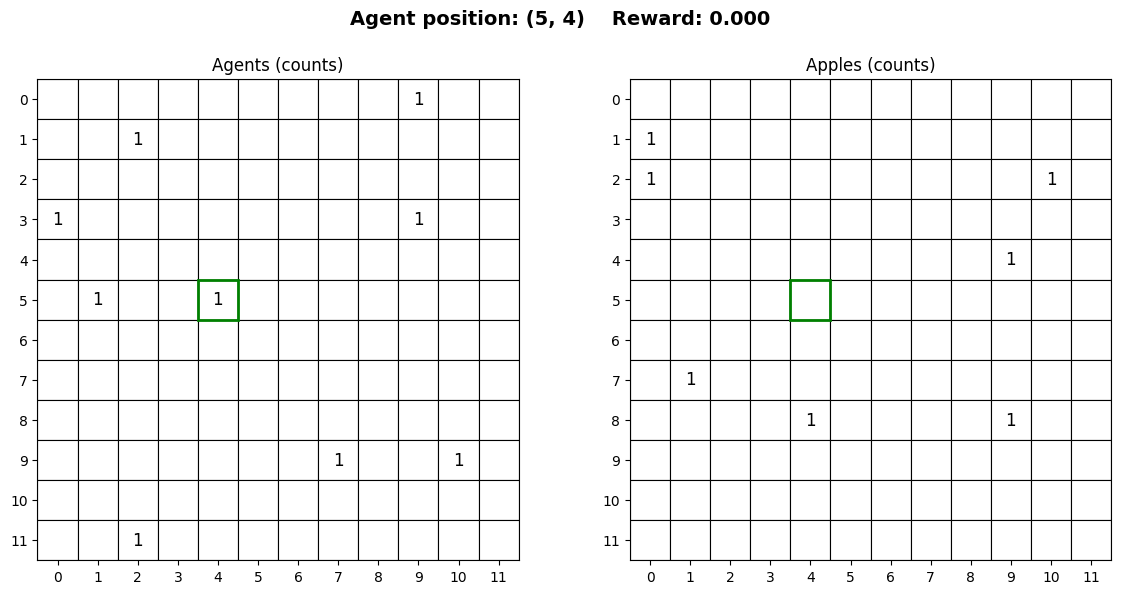

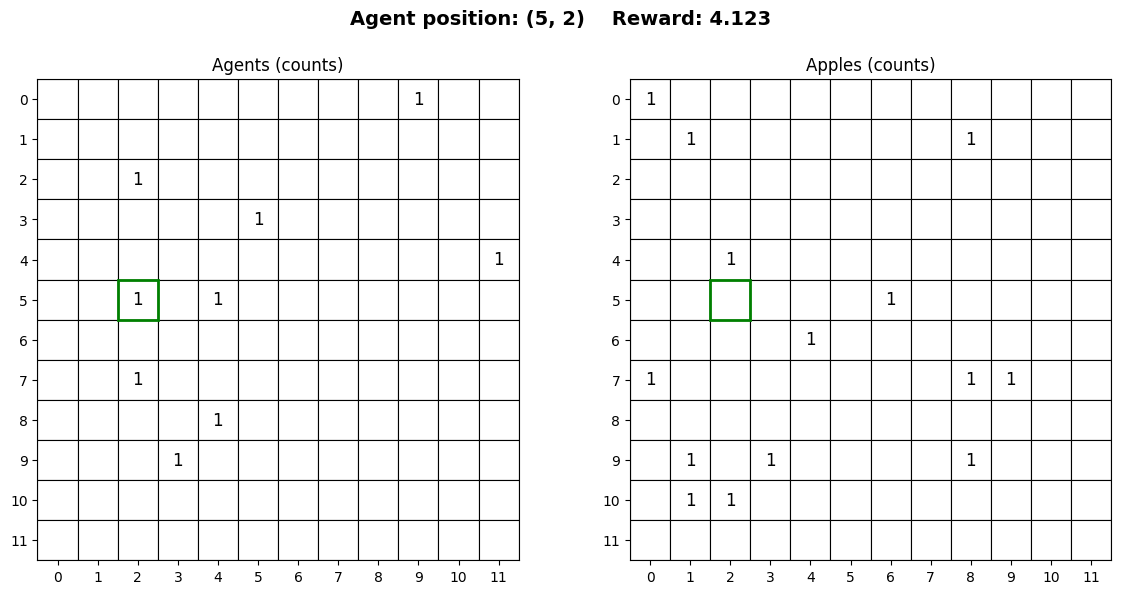

In [13]:
for i in range(3):
    visualize_state_counts(training_data[i])

In [7]:
model = RewardCNNDecentralized(WIDTH, HEIGHT, LEARNING_RATE, mlp_hidden_features=MLP_HIDDEN_FEATURES, num_mlp_hidden_layers=MLP_HIDDEN_LAYERS)
for epoch in range(NUM_EPOCHS):
    print(f"--- Starting Epoch {epoch+1}/{NUM_EPOCHS} ---")
    # Shuffle the training data at the beginning of each epoch
    random.shuffle(training_data)

    # Use tqdm for a progress bar over the batches
    progress_bar = tqdm(range(0, TOTAL_TRAIN_SAMPLES, BATCH_SIZE), desc=f"Epoch {epoch+1} Training")

    for i in progress_bar:
        # Get a slice of the data for the current mini-batch
        batch = training_data[i : i + BATCH_SIZE]
        
        # Process each sample in the mini-batch
        for sample in batch:
            state = sample['state']
            agent_pos = sample['agent_pos']
            reward = sample['reward']
            
            # Add experience to the model's internal buffer
            model.add_experience_from_raw(state, reward, agent_pos=agent_pos)

        # After processing the whole batch, perform one training step
        loss = model.train_batch()
        
        # Update the progress bar with the latest loss
        if loss is not None:
            progress_bar.set_postfix(loss=f"{loss:.4f}")

--- Starting Epoch 1/10 ---


Epoch 1 Training: 100%|██████████| 1563/1563 [00:09<00:00, 166.20it/s, loss=0.1513]


--- Starting Epoch 2/10 ---


Epoch 2 Training: 100%|██████████| 1563/1563 [00:08<00:00, 187.50it/s, loss=0.0452]


--- Starting Epoch 3/10 ---


...

Epoch 8 Training: 100%|██████████| 1563/1563 [00:07<00:00, 197.61it/s, loss=0.0151]


--- Starting Epoch 9/10 ---


Epoch 9 Training: 100%|██████████| 1563/1563 [00:09<00:00, 171.03it/s, loss=0.0069]


--- Starting Epoch 10/10 ---


Epoch 10 Training: 100%|██████████| 1563/1563 [00:06<00:00, 229.19it/s, loss=0.0043]


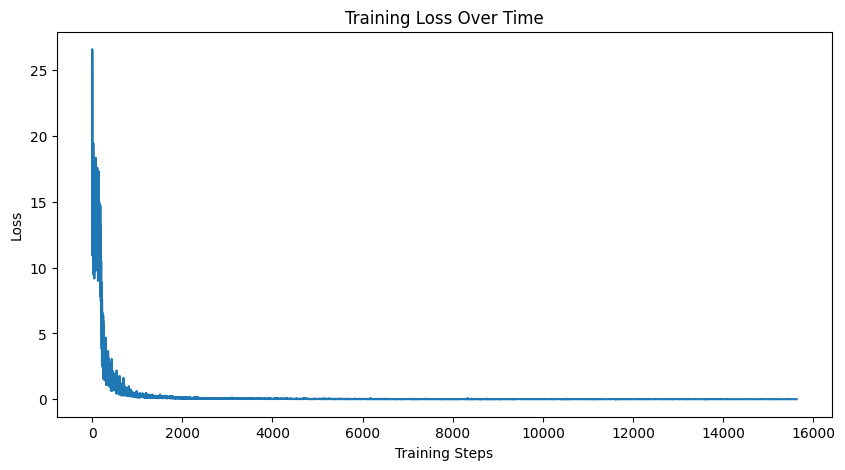

final training loss: 0.00431455485522747


In [8]:
# PLOT TRAINING LOSS
plt.figure(figsize=(10, 5))
plt.plot(model.loss_history, label='Training Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.show()

print("final training loss:", model.loss_history[-1])

# TEST MODEL

In [9]:
# --- Step 2: Initialize Variables for Metrics ---
num_correct = 0
total_predictions = len(testing_data)
errors = [] # We'll store all the absolute errors to calculate MAE and RMSE efficiently

errors_when_reward_bigger_than_0 = []  # Store errors when true reward is greater than 0
errors_when_reward_minus_one = []  # Store errors when true reward is -1
errors_when_reward_zero = []  # Store errors when true reward is 0

# --- Step 3: The Evaluation Loop ---
print("\n--- Starting Evaluation on Test Set ---")
# No need to shuffle the test set.
for sample in tqdm(testing_data, desc="Evaluating"):
    state = sample['state']
    agent_pos = sample['agent_pos']
    true_reward = sample['reward']
    
    # Get the model's prediction. The .item() is important to get a single float.
    predicted_reward = model.get_model_reward_prediction_from_raw(state, agent_pos=agent_pos).item()
    
    # Calculate the absolute error
    error = abs(predicted_reward - true_reward)
    errors.append(error)
    if true_reward > 0:
        errors_when_reward_bigger_than_0.append(error)
    if true_reward == -1:
        errors_when_reward_minus_one.append(error)
    if true_reward == 0:
        errors_when_reward_zero.append(error)

accuracy = num_correct / total_predictions

# Standard regression metrics
# Ensure errors list is not empty to avoid division by zero
if errors:
    mean_absolute_error = np.mean(errors)
    root_mean_squared_error = np.sqrt(np.mean(np.square(errors)))
else:
    mean_absolute_error = float('nan')
    root_mean_squared_error = float('nan')
    
if errors_when_reward_bigger_than_0:
    mae_when_reward_bigger_than_0 = np.mean(errors_when_reward_bigger_than_0)
    root_mean_squared_error_when_reward_bigger_than_0 = np.sqrt(np.mean(np.square(errors_when_reward_bigger_than_0)))
else:
    mae_when_reward_bigger_than_0 = float('nan')
    root_mean_squared_error_when_reward_bigger_than_0 = float('nan')
    
if errors_when_reward_minus_one:
    mae_when_reward_minus_one = np.mean(errors_when_reward_minus_one)
    root_mean_squared_error_when_reward_minus_one = np.sqrt(np.mean(np.square(errors_when_reward_minus_one)))
else:
    mae_when_reward_minus_one = float('nan')
    root_mean_squared_error_when_reward_minus_one = float('nan')
    
if errors_when_reward_zero:
    mae_when_reward_zero = np.mean(errors_when_reward_zero)
    root_mean_squared_error_when_reward_zero = np.sqrt(np.mean(np.square(errors_when_reward_zero)))
else:
    mae_when_reward_zero = float('nan')
    root_mean_squared_error_when_reward_zero = float('nan')




--- Starting Evaluation on Test Set ---


Evaluating: 100%|██████████| 20000/20000 [00:11<00:00, 1678.12it/s]


In [10]:
print("\n--- Total Evaluation Results ---")
print("Total samples evaluated:", total_predictions)
print(f"Total Mean Absolute Error (MAE): {mean_absolute_error:.4f}")
print(f"Total Root Mean Squared Error (RMSE): {root_mean_squared_error:.4f}")
print("----- When reward > 0 -----")
print("Samples with true reward > 0:", len(errors_when_reward_bigger_than_0))
print(f"MAE when true reward > 0: {mae_when_reward_bigger_than_0:.4f}")
print(f"RMSE when true reward > 0: {root_mean_squared_error_when_reward_bigger_than_0:.4f}")
print("----- When reward = -1 -----")
print("Samples with true reward = -1:", len(errors_when_reward_minus_one))
print(f"MAE when true reward = -1: {mae_when_reward_minus_one:.4f}")
print(f"RMSE when true reward = -1: {root_mean_squared_error_when_reward_minus_one:.4f}")
print("----- When reward = 0 -----")
print("Samples with true reward = 0:", len(errors_when_reward_zero))
print(f"MAE when true reward = 0: {mae_when_reward_zero:.4f}")
print(f"RMSE when true reward = 0: {root_mean_squared_error_when_reward_zero:.4f}")


--- Total Evaluation Results ---
Total samples evaluated: 20000
Total Mean Absolute Error (MAE): 0.0433
Total Root Mean Squared Error (RMSE): 0.0711
----- When reward > 0 -----
Samples with true reward > 0: 8958
MAE when true reward > 0: 0.0815
RMSE when true reward > 0: 0.1049
----- When reward = -1 -----
Samples with true reward = -1: 1165
MAE when true reward = -1: 0.0192
RMSE when true reward = -1: 0.0232
----- When reward = 0 -----
Samples with true reward = 0: 9877
MAE when true reward = 0: 0.0115
RMSE when true reward = 0: 0.0144


In [ ]:
import pickle

# --- Step 4: Save the Results ---
# The filename is generated dynamically from the parameters
output_filename = f"results_{WIDTH}x{HEIGHT}_{NUM_AGENTS}agents_{PROBABILITY_AN_APPLE_IS_PICKED}p_pick.pkl"

results_to_save = {
    'width': WIDTH,
    'height': HEIGHT,
    'num_agents': NUM_AGENTS,
    'p_pick': PROBABILITY_AN_APPLE_IS_PICKED,
    'errors': errors  # The list of errors calculated in the previous cell
}

with open(output_filename, 'wb') as f:
    pickle.dump(results_to_save, f)

print(f"Results saved to {output_filename}")